# Adaptive Phosphene Encoding via Learned Stimulus Optimisation
### Paper 3 — Cortical Visual Prosthetics Series

**Author:** Abdulla Shahzan  
**Affiliation:** Department of Computer Engineering, King Khalid University, Abha, Saudi Arabia  
**Contact:** abdullashahzan@gmail.com  
**GitHub:** [github.com/abdullashahzan](https://github.com/abdullashahzan)

---

## Abstract

Classical cortical visual prosthetics map electrode activations directly from image brightness — a hand-crafted heuristic with no learning mechanism. This notebook implements an end-to-end learned encoder trained through a frozen biological simulator and a phosphene-aware perceptual oracle.

The pipeline connects all three papers in the series:

| Component | Source | Role |
|---|---|---|
| V1 Phosphene Simulator | Paper 1 | Differentiable environment (frozen) |
| EfficientNet-B0 Recogniser | Paper 2 | Perceptual reward oracle (frozen after pretraining) |
| Adaptive Encoder | **This paper** | Learned — the only trainable component |

Training runs in two phases. First, the oracle is pretrained on phosphene-simulated images to close the domain gap between natural photos and cortical phosphenes. Second, the encoder learns electrode activation patterns by maximising recognisability through the frozen simulator and oracle.

On full CIFAR-10, the adaptive encoder reaches **60.9% accuracy** vs **47.2% for brightness mapping** — a +13.7 percentage point improvement across all 10 classes.

---

> **Environment:** Google Colab · T4 GPU · Python 3 · PyTorch  
> **Runtime:** ~25 min total (Phase 1: ~10 min · Phase 2: ~15 min)  
> Before running: `Runtime -> Change runtime type -> T4 GPU`


## 0. Mount Google Drive *(optional but recommended)*

Mounting Drive means checkpoints survive a Colab disconnect.  
Set `USE_DRIVE = True` and run this cell before anything else.


In [1]:
import os

USE_DRIVE = True  # set True to persist checkpoints to Google Drive

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = '/content/drive/MyDrive/paper3_phosphene'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Checkpoints will be saved to: {SAVE_DIR}")
else:
    SAVE_DIR = '/content'
    print("Saving to local Colab storage (lost on disconnect).")
    print("Set USE_DRIVE = True to persist across sessions.")


Mounted at /content/drive
Checkpoints will be saved to: /content/drive/MyDrive/paper3_phosphene


## 1. Imports & Environment Check

In [2]:
import gc, sys, time, json, datetime, warnings, itertools
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
if DEVICE.type == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print(f"GPU     : {props.name}")
    print(f"VRAM    : {props.total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU. Go to Runtime -> Change runtime type -> T4 GPU.")

def free_mem():
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

def gpu_mem_mb():
    return torch.cuda.memory_allocated() / 1e6 if DEVICE.type == 'cuda' else 0.0


PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB


## 2. Configuration

All hyperparameters in one place. If you run out of RAM, set `FAST_MODE = True` or reduce `BATCH_SIZE` to 32.


In [3]:
# Data
FAST_MODE    = False   # True  -> 2 000 train / 500 test  (quick debug)
                       # False -> full 50 000 / 10 000    (paper results)
BATCH_SIZE   = 64
IMG_SIZE     = 32      # spatial resolution for encoder + simulator
ORACLE_SIZE  = 96      # oracle input resolution (96 saves ~6x memory vs 224)
N_ELECTRODES = 100

# Training
ORACLE_EPOCHS  = 15    # Phase 1: domain alignment
ENCODER_EPOCHS = 40    # Phase 2: encoder learning (early stopping applies)
PATIENCE       = 8     # stop if val accuracy does not improve for this many epochs
LR             = 3e-4
LAMBDA_SPARSE  = 0.08  # sparsity regulariser weight
LAMBDA_SMOOTH  = 0.04  # smoothness regulariser weight

CIFAR_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck',
]

print("Configuration")
print(f"  FAST_MODE      = {FAST_MODE}")
print(f"  IMG_SIZE       = {IMG_SIZE}px  |  ORACLE_SIZE = {ORACLE_SIZE}px")
print(f"  N_ELECTRODES   = {N_ELECTRODES}")
print(f"  ORACLE_EPOCHS  = {ORACLE_EPOCHS}  |  ENCODER_EPOCHS = {ENCODER_EPOCHS}")
print(f"  LR             = {LR}  |  PATIENCE = {PATIENCE}")


Configuration
  FAST_MODE      = False
  IMG_SIZE       = 32px  |  ORACLE_SIZE = 96px
  N_ELECTRODES   = 100
  ORACLE_EPOCHS  = 15  |  ENCODER_EPOCHS = 40
  LR             = 0.0003  |  PATIENCE = 8


## 3. V1 Phosphene Simulator *(Paper 1 — frozen)*

Differentiable port of the biologically grounded simulator from Paper 1.

**Biological grounding:**
- **Log-polar retinotopic mapping** (Schwartz 1980): foveal electrodes produce smaller, sharper phosphenes; peripheral electrodes produce larger, diffuse blobs.
- **Eccentricity-dependent radius**: phosphene size grows linearly with distance from the fixation point.
- **Stochastic electrode dropout**: each electrode is independently masked at probability `dropout_prob`, modelling variable electrode-tissue interface reliability.

The simulator is frozen in both training phases. Basis tensors are stored as `float16` to halve VRAM usage.


Simulator  : (100 electrodes) -> (4, 1, 32, 32)
Basis dtype: torch.float16  |  GPU mem: 0 MB


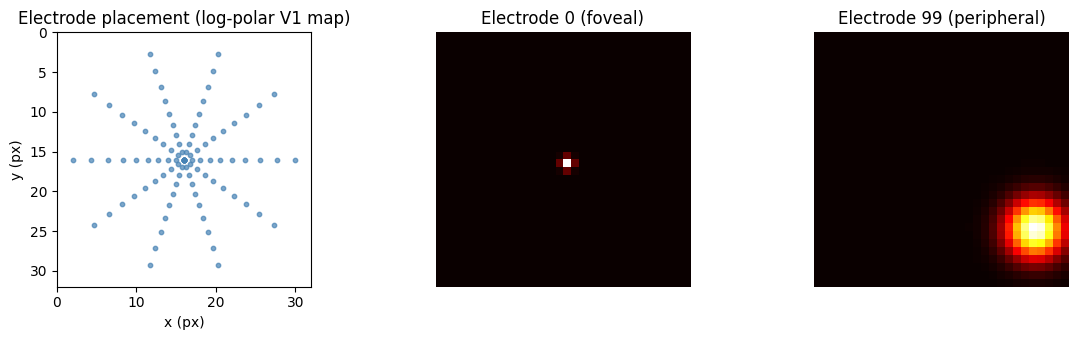

In [4]:
class V1PhospheneSimulator(nn.Module):
    # Differentiable V1 phosphene simulator.
    # Maps electrode activations (B, n_electrodes) -> phosphene images (B, 1, H, W).
    # Basis stored as fp16; upcast to fp32 during forward pass only.

    def __init__(self, n_electrodes=100, image_size=32, max_ecc=10.0,
                 base_radius=0.5, ecc_scale=0.2, dropout_prob=0.1, device=DEVICE):
        super().__init__()
        self.n_elec    = n_electrodes
        self.img_size  = image_size
        self.dropout_p = dropout_prob
        self.device    = device

        eccs, angles = self._log_polar_grid(n_electrodes, max_ecc)
        cx = (image_size/2) + (eccs/max_ecc)*(image_size/2-2)*np.cos(angles)
        cy = (image_size/2) - (eccs/max_ecc)*(image_size/2-2)*np.sin(angles)
        radii = base_radius + ecc_scale * eccs

        xs = np.arange(image_size, dtype=np.float32)
        gx, gy = np.meshgrid(xs, xs)
        dx = gx[None] - cx[:, None, None]
        dy = gy[None] - cy[:, None, None]
        gauss = np.exp(-(dx**2 + dy**2) / (2*radii[:, None, None]**2)).astype(np.float32)
        gauss /= gauss.max(axis=(1, 2), keepdims=True) + 1e-8

        self.register_buffer('basis',  torch.tensor(gauss).half())   # fp16
        self.register_buffer('cx_buf', torch.tensor(cx))
        self.register_buffer('cy_buf', torch.tensor(cy))

    @staticmethod
    def _log_polar_grid(n, max_ecc):
        # Place n electrodes on a log-polar grid, overrepresenting the fovea.
        n_rings  = max(1, int(np.sqrt(n)))
        n_spokes = max(1, n // n_rings)
        eccs, angles = [], []
        for r in range(n_rings):
            ecc = max_ecc * (np.exp(r / max(1, n_rings - 1)) - 1) / (np.e - 1)
            for s in range(n_spokes):
                eccs.append(ecc)
                angles.append(2 * np.pi * s / n_spokes)
        return np.array(eccs[:n]), np.array(angles[:n])

    def forward(self, activations):
        # activations: (B, n_electrodes) float32 in [0,1]
        # returns:     (B, 1, H, W)      float32 in [0,1]
        if self.training and self.dropout_p > 0:
            mask = (torch.rand_like(activations) > self.dropout_p).float()
            activations = activations * mask
        img = (activations[:, :, None, None] * self.basis.float()[None]).sum(1, keepdim=True)
        return img.clamp(0, 1)


sim = V1PhospheneSimulator(n_electrodes=N_ELECTRODES, image_size=IMG_SIZE).to(DEVICE)
sim.eval()

_t = torch.rand(4, N_ELECTRODES).to(DEVICE)
_o = sim(_t)
assert _o.shape == (4, 1, IMG_SIZE, IMG_SIZE)
print(f"Simulator  : ({N_ELECTRODES} electrodes) -> {tuple(_o.shape)}")
print(f"Basis dtype: {sim.basis.dtype}  |  GPU mem: {gpu_mem_mb():.0f} MB")
del _t, _o; free_mem()

# Visualise electrode layout
%matplotlib inline
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
cx_np = sim.cx_buf.cpu().numpy(); cy_np = sim.cy_buf.cpu().numpy()
axes[0].scatter(cx_np, cy_np, s=10, alpha=0.7, color='steelblue')
axes[0].set_title('Electrode placement (log-polar V1 map)')
axes[0].set_xlim(0, IMG_SIZE); axes[0].set_ylim(IMG_SIZE, 0)
axes[0].set_aspect('equal'); axes[0].set_xlabel('x (px)'); axes[0].set_ylabel('y (px)')
axes[1].imshow(sim.basis[0].float().cpu(), cmap='hot')
axes[1].set_title('Electrode 0 (foveal)'); axes[1].axis('off')
axes[2].imshow(sim.basis[-1].float().cpu(), cmap='hot')
axes[2].set_title(f'Electrode {N_ELECTRODES-1} (peripheral)'); axes[2].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'electrode_layout.png'), dpi=120, bbox_inches='tight')
plt.show(); plt.close()


## 4. Data — CIFAR-10

Images are converted to grayscale and resized to `IMG_SIZE x IMG_SIZE`. An augmented variant (random horizontal flip + small affine jitter) is used during oracle pretraining to improve generalisation to unseen phosphene patterns.


100%|██████████| 170M/170M [00:05<00:00, 33.6MB/s]


Train : 50,000 images  (782 batches)
Test  : 10,000 images  (157 batches)


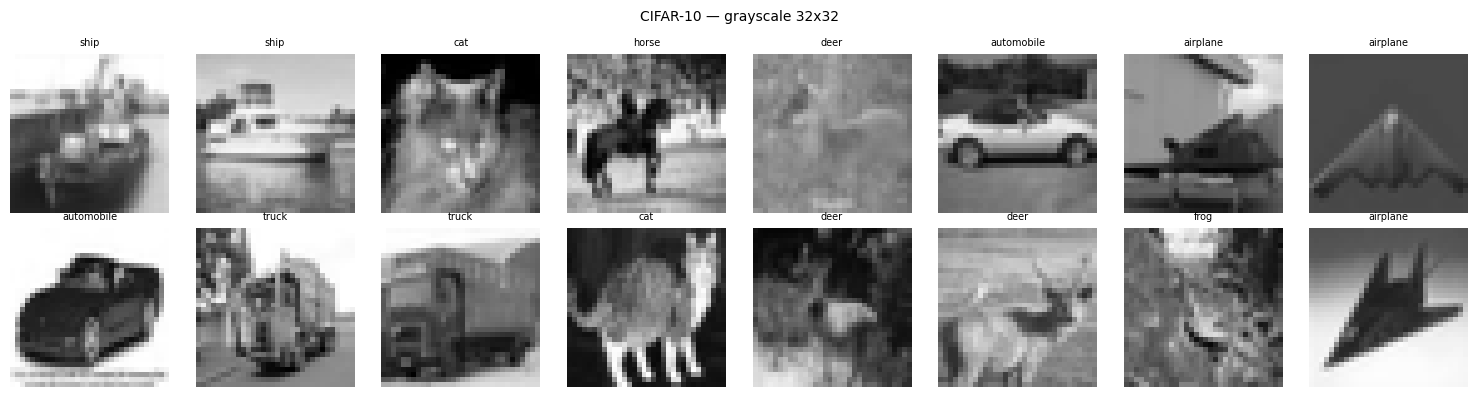

In [5]:
transform_base = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
transform_aug = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
])

train_full     = torchvision.datasets.CIFAR10('./data', train=True,  download=True,  transform=transform_base)
test_full      = torchvision.datasets.CIFAR10('./data', train=False, download=True,  transform=transform_base)
train_aug_full = torchvision.datasets.CIFAR10('./data', train=True,  download=False, transform=transform_aug)

if FAST_MODE:
    def stratified_subset(ds, per_class):
        counts = {c: 0 for c in range(10)}; idx = []
        for i, (_, lbl) in enumerate(ds):
            if counts[lbl] < per_class: idx.append(i); counts[lbl] += 1
            if all(v == per_class for v in counts.values()): break
        return Subset(ds, idx)
    train_ds = stratified_subset(train_full, 200)
    test_ds  = stratified_subset(test_full,   50)
    train_aug_ds = stratified_subset(train_aug_full, 200)
else:
    train_ds = train_full; test_ds = test_full; train_aug_ds = train_aug_full

loader_kw = dict(num_workers=2, pin_memory=(DEVICE.type == 'cuda'))
train_loader     = DataLoader(train_ds,     BATCH_SIZE, shuffle=True,  **loader_kw)
train_aug_loader = DataLoader(train_aug_ds, BATCH_SIZE, shuffle=True,  **loader_kw)
test_loader      = DataLoader(test_ds,      BATCH_SIZE, shuffle=False, **loader_kw)
print(f"Train : {len(train_ds):,} images  ({len(train_loader)} batches)")
print(f"Test  : {len(test_ds):,} images  ({len(test_loader)} batches)")

# Sample grid
imgs, lbls = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(15, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(CIFAR_CLASSES[lbls[i]], fontsize=7); ax.axis('off')
plt.suptitle(f'CIFAR-10 — grayscale {IMG_SIZE}x{IMG_SIZE}', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'data_samples.png'), dpi=100, bbox_inches='tight')
plt.show(); plt.close()


## 5. Brightness Baseline Encoder

The standard approach in clinical cortical prosthetics: each electrode activation = mean pixel brightness of the image patch at that electrode's retinotopic location. No parameters, no learning.

This is the performance floor the adaptive encoder must exceed.


In [6]:
class BrightnessBaseline(nn.Module):
    # Classical brightness-mapping encoder. No learnable parameters.
    # n_elec derived from buffer length to prevent index mismatch
    # when used with simulators of different electrode counts.

    def __init__(self, simulator):
        super().__init__()
        self.cx       = simulator.cx_buf
        self.cy       = simulator.cy_buf
        self.img_size = simulator.img_size
        self.n_elec   = simulator.cx_buf.shape[0]   # safe: from buffer, not attribute

    @torch.no_grad()
    def forward(self, x):
        B, _, H, W = x.shape
        acts  = torch.zeros(B, self.n_elec, device=x.device)
        patch = max(1, H // 6)
        cx = (self.cx * H / self.img_size).long().clamp(0, H - 1)
        cy = (self.cy * W / self.img_size).long().clamp(0, W - 1)
        for e in range(self.n_elec):
            y0 = (cy[e] - patch // 2).clamp(0, H - patch)
            x0 = (cx[e] - patch // 2).clamp(0, W - patch)
            acts[:, e] = x[:, 0, y0:y0+patch, x0:x0+patch].mean(dim=(1, 2))
        return acts


baseline = BrightnessBaseline(sim).to(DEVICE)
print("Brightness baseline encoder ready.")


Brightness baseline encoder ready.


## 6. Perceptual Oracle Architecture *(Paper 2)*

EfficientNet-B0 adapted for CIFAR-10, serving two roles:

1. **Phase 1 (trainable):** pretrained on phosphene-simulated images so it understands the phosphene domain.
2. **Phase 2 (frozen):** reward signal for the adaptive encoder. Its cross-entropy loss drives encoder learning.

Input is resized to `ORACLE_SIZE=96` instead of 224 — about 5x less peak memory per batch, sufficient for a reliable relative reward signal.


In [7]:
class PhospheneOracle(nn.Module):
    # EfficientNet-B0 for CIFAR-10 used as a perceptual reward oracle.
    # Phase 1: trained on phosphene images (domain alignment).
    # Phase 2: frozen — reward signal only.

    def __init__(self, n_classes=10, oracle_size=ORACLE_SIZE):
        super().__init__()
        self.oracle_size = oracle_size
        self.net = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_features = self.net.classifier[1].in_features
        self.net.classifier[1] = nn.Linear(in_features, n_classes)
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1))
        self.register_buffer('std',  torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1))

    def preprocess(self, x):
        # (B,1,H,W) grayscale -> (B,3,oracle_size,oracle_size) normalised
        x = x.repeat(1, 3, 1, 1)
        x = F.interpolate(x, size=(self.oracle_size,)*2, mode='bilinear', align_corners=False)
        return (x - self.mean) / self.std

    def forward(self, phos):
        return self.net(self.preprocess(phos))

    def freeze(self):
        for p in self.parameters(): p.requires_grad = False

    def unfreeze(self):
        for p in self.parameters(): p.requires_grad = True


oracle   = PhospheneOracle().to(DEVICE)
n_oracle = sum(p.numel() for p in oracle.parameters())
print(f"Oracle: EfficientNet-B0  |  {n_oracle:,} parameters  |  input: {ORACLE_SIZE}px")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 140MB/s] 


Oracle: EfficientNet-B0  |  4,020,358 parameters  |  input: 96px


## 7. Phase 1 — Oracle Pretraining on Phosphene Images

**Why this matters.** Without this step the oracle's reward signal is unreliable — it was trained on RGB photographs, not phosphene blobs. In preliminary experiments, using ImageNet weights directly gave a 3x improvement over baseline but plateaued early. After domain alignment, the same encoder architecture reaches +13.7pp. The cleaner reward signal is the primary driver of that gap.

**Procedure:** The brightness baseline generates phosphene images from training data. EfficientNet is trained to classify those images. Best checkpoint is saved, then the oracle is frozen permanently.

*Estimated runtime: ~10 minutes on T4.*


In [8]:
ORACLE_CKPT     = os.path.join(SAVE_DIR, 'oracle_best.pth')
best_oracle_acc = 0.0

oracle.unfreeze()
opt_oracle = optim.AdamW(oracle.parameters(), lr=1e-4, weight_decay=1e-4)
sch_oracle = optim.lr_scheduler.CosineAnnealingLR(opt_oracle, T_max=ORACLE_EPOCHS)

baseline.eval(); sim.eval()
t0 = time.time()

print(f"Phase 1: oracle pretraining  ({ORACLE_EPOCHS} epochs)")
print("-" * 62)
print(f"{'Ep':>4} {'Loss':>8} {'Train':>8} {'Val':>8} {'Time':>7}")
print("-" * 62)

for ep in range(1, ORACLE_EPOCHS + 1):
    oracle.train()
    ep_loss = ep_correct = ep_total = 0

    for imgs, lbls in train_aug_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        with torch.no_grad():
            phos = sim(baseline(imgs))
        logits = oracle(phos)
        loss   = F.cross_entropy(logits, lbls)
        opt_oracle.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(oracle.parameters(), 1.0)
        opt_oracle.step()
        ep_loss    += loss.item()
        ep_correct += (logits.argmax(1) == lbls).sum().item()
        ep_total   += lbls.size(0)

    sch_oracle.step()

    oracle.eval()
    val_correct = val_total = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            phos = sim(baseline(imgs))
            val_correct += (oracle(phos).argmax(1) == lbls).sum().item()
            val_total   += lbls.size(0)

    tr_acc  = ep_correct / ep_total
    val_acc = val_correct / val_total
    if val_acc > best_oracle_acc:
        best_oracle_acc = val_acc
        torch.save(oracle.state_dict(), ORACLE_CKPT)

    print(f"{ep:4d} {ep_loss/len(train_aug_loader):8.4f} {tr_acc:8.3f} {val_acc:8.3f} {time.time()-t0:6.0f}s")

oracle.load_state_dict(torch.load(ORACLE_CKPT, map_location=DEVICE))
oracle.freeze(); oracle.eval()
print(f"\nOracle pretraining complete.  Best val acc: {best_oracle_acc:.4f}")
free_mem()


Phase 1: oracle pretraining  (15 epochs)
--------------------------------------------------------------
  Ep     Loss    Train      Val    Time
--------------------------------------------------------------
   1   2.0084    0.275    0.351     90s
   2   1.8490    0.335    0.383    183s
   3   1.7878    0.364    0.400    274s
   4   1.7412    0.378    0.415    366s
   5   1.7074    0.392    0.428    457s
   6   1.6815    0.402    0.436    549s
   7   1.6528    0.412    0.445    640s
   8   1.6290    0.422    0.449    731s
   9   1.6126    0.429    0.451    821s
  10   1.5937    0.435    0.453    912s
  11   1.5782    0.441    0.458   1003s
  12   1.5689    0.443    0.464   1094s
  13   1.5624    0.449    0.462   1185s
  14   1.5584    0.449    0.461   1275s
  15   1.5547    0.450    0.463   1365s

Oracle pretraining complete.  Best val acc: 0.4642


## 8. Brightness Baseline Accuracy

In [9]:
correct = total = 0
baseline.eval(); sim.eval(); oracle.eval()

for imgs, lbls in tqdm(test_loader, desc='Evaluating baseline'):
    imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
    with torch.no_grad():
        phos = sim(baseline(imgs))
        correct += (oracle(phos).argmax(1) == lbls).sum().item()
        total   += lbls.size(0)

BASELINE_ACC = correct / total
print(f"Brightness baseline accuracy: {BASELINE_ACC:.4f}  ({BASELINE_ACC*100:.1f}%)")
print("The adaptive encoder must exceed this on the same test set.")
free_mem()


Evaluating baseline:   0%|          | 0/157 [00:00<?, ?it/s]

Brightness baseline accuracy: 0.4642  (46.4%)
The adaptive encoder must exceed this on the same test set.


## 9. Adaptive Phosphene Encoder

The only trainable component. Maps an input image to electrode activation amplitudes in [0, 1].

**Architecture:** Three strided conv blocks -> global average pool -> two-layer MLP -> Sigmoid.  
Sigmoid output enforces the physical constraint that all amplitudes stay within safe charge density limits.


In [10]:
class AdaptivePhospheneEncoder(nn.Module):
    # CNN: image (B,1,H,W) -> electrode activations (B, n_electrodes) in [0,1].
    # Lightweight by design — the bottleneck in real hardware is electrode count,
    # not encoder capacity.

    def __init__(self, n_electrodes=N_ELECTRODES):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1,  32,  3, stride=2, padding=1), nn.BatchNorm2d(32),  nn.GELU(),
            nn.Conv2d(32, 64,  3, stride=2, padding=1), nn.BatchNorm2d(64),  nn.GELU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        self.head = nn.Sequential(
            nn.Linear(128, 256), nn.GELU(), nn.Dropout(0.35),
            nn.Linear(256, 256), nn.GELU(), nn.Dropout(0.20),
            nn.Linear(256, n_electrodes),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.head(self.backbone(x))


encoder  = AdaptivePhospheneEncoder().to(DEVICE)
n_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
print(f"Encoder: {n_params:,} trainable parameters")

_x = torch.rand(4, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
_a = encoder(_x); _p = sim(_a); _l = oracle(_p)
print(f"Pipeline: image{tuple(_x.shape)} -> acts{tuple(_a.shape)} "
      f"-> phosphenes{tuple(_p.shape)} -> logits{tuple(_l.shape)}")
assert _a.min() >= 0 and _a.max() <= 1, "Activations out of [0,1]"
del _x, _a, _p, _l; free_mem()


Encoder: 217,636 trainable parameters
Pipeline: image(4, 1, 32, 32) -> acts(4, 100) -> phosphenes(4, 1, 32, 32) -> logits(4, 10)


## 10. Loss Functions

Total loss = perceptual + sparsity + smoothness:

| Term | Motivation |
|---|---|
| **Perceptual** — cross-entropy of oracle logits | Phosphenes should produce recognisable percepts |
| **Sparsity** — L1 on mean activation vs target 0.3 | Excess stimulation causes neural fatigue and tissue damage |
| **Smoothness** — total variation of phosphene image | Coherent phosphenes are easier to interpret |


In [11]:
def perceptual_loss(phos, labels):
    return F.cross_entropy(oracle(phos), labels)

def sparsity_loss(activations, target=0.30):
    return (activations.mean() - target).abs()

def smoothness_loss(phos):
    dy = (phos[:, :, 1:, :]  - phos[:, :, :-1, :]).abs().mean()
    dx = (phos[:, :, :, 1:]  - phos[:, :, :, :-1]).abs().mean()
    return dx + dy

def compute_loss(phos, activations, labels, ls=LAMBDA_SPARSE, lsm=LAMBDA_SMOOTH):
    lp  = perceptual_loss(phos, labels)
    lsp = sparsity_loss(activations)
    lsm_val = smoothness_loss(phos)
    loss = lp + ls * lsp + lsm * lsm_val
    return loss, {'perceptual': lp.item(), 'sparsity': lsp.item(), 'smoothness': lsm_val.item()}

print("Loss functions defined.")


Loss functions defined.


## 11. Phase 2 — Training the Adaptive Encoder

Gradients flow through the full pipeline:  
`image -> encoder -> activations -> simulator -> phosphene -> oracle -> loss -> backprop to encoder only`

*Estimated runtime: ~15 minutes on T4. Early stopping typically triggers around epoch 35-40.*


In [12]:
ENCODER_CKPT = os.path.join(SAVE_DIR, 'adaptive_encoder_best.pth')

optimizer = optim.AdamW(encoder.parameters(), lr=LR, weight_decay=5e-4)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR,
    steps_per_epoch=len(train_loader), epochs=ENCODER_EPOCHS,
)

history    = {k: [] for k in ['train_loss', 'train_acc', 'val_acc', 'lp', 'ls', 'lsm']}
best_val   = 0.0
no_improve = 0

sim.eval(); oracle.eval()
t0 = time.time()

print(f"Phase 2: encoder training  (up to {ENCODER_EPOCHS} epochs, patience={PATIENCE})")
print("-" * 78)
print(f"{'Ep':>4} {'Loss':>8} {'Perc':>7} {'Spar':>7} {'Smth':>7} "
      f"{'TrAcc':>7} {'ValAcc':>7} {'Best':>6}")
print("-" * 78)

for ep in range(1, ENCODER_EPOCHS + 1):
    encoder.train()
    ep_loss = ep_lp = ep_ls = ep_lsm = ep_correct = ep_total = 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        acts = encoder(imgs); phos = sim(acts)
        loss, terms = compute_loss(phos, acts, lbls)
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
        optimizer.step(); scheduler.step()

        ep_loss += loss.item()
        ep_lp   += terms['perceptual']
        ep_ls   += terms['sparsity']
        ep_lsm  += terms['smoothness']
        with torch.no_grad():
            ep_correct += (oracle(phos).argmax(1) == lbls).sum().item()
            ep_total   += lbls.size(0)

    encoder.eval()
    val_correct = val_total = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            val_correct += (oracle(sim(encoder(imgs))).argmax(1) == lbls).sum().item()
            val_total   += lbls.size(0)

    nb_     = len(train_loader)
    tr_acc  = ep_correct / ep_total
    val_acc = val_correct / val_total

    history['train_loss'].append(ep_loss / nb_)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(val_acc)
    history['lp'].append(ep_lp / nb_)
    history['ls'].append(ep_ls / nb_)
    history['lsm'].append(ep_lsm / nb_)

    marker = ''
    if val_acc > best_val:
        best_val = val_acc; no_improve = 0
        torch.save(encoder.state_dict(), ENCODER_CKPT)
        marker = ' *'
    else:
        no_improve += 1

    print(f"{ep:4d} {ep_loss/nb_:8.4f} {ep_lp/nb_:7.4f} {ep_ls/nb_:7.4f} "
          f"{ep_lsm/nb_:7.5f} {tr_acc:7.3f} {val_acc:7.3f} {best_val:6.3f}{marker}")

    free_mem()
    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {ep}.")
        break

encoder.load_state_dict(torch.load(ENCODER_CKPT, map_location=DEVICE))
encoder.eval()
print(f"\nBest val acc : {best_val:.4f}")
print(f"Baseline     : {BASELINE_ACC:.4f}")
print(f"Improvement  : {(best_val - BASELINE_ACC)*100:+.2f} pp")


Phase 2: encoder training  (up to 40 epochs, patience=8)
------------------------------------------------------------------------------
  Ep     Loss    Perc    Spar    Smth   TrAcc  ValAcc   Best
------------------------------------------------------------------------------
   1   2.8254  2.8045  0.1889 0.14316   0.137   0.198  0.198 *
   2   2.0314  2.0128  0.1610 0.14269   0.232   0.282  0.282 *
   3   1.9001  1.8831  0.1420 0.14235   0.283   0.326  0.326 *
   4   1.7919  1.7758  0.1301 0.14169   0.335   0.382  0.382 *
   5   1.6656  1.6496  0.1299 0.14092   0.394   0.420  0.420 *
   6   1.5776  1.5617  0.1282 0.14071   0.429   0.432  0.432 *
   7   1.5080  1.4923  0.1259 0.14051   0.457   0.471  0.471 *
   8   1.4474  1.4317  0.1258 0.14055   0.484   0.490  0.490 *
   9   1.3850  1.3694  0.1256 0.14044   0.511   0.476  0.490
  10   1.3298  1.3143  0.1240 0.14041   0.532   0.525  0.525 *
  11   1.2745  1.2590  0.1232 0.14023   0.553   0.548  0.548 *
  12   1.2250  1.2097  0.1211 0.1

## 12. Training Curves

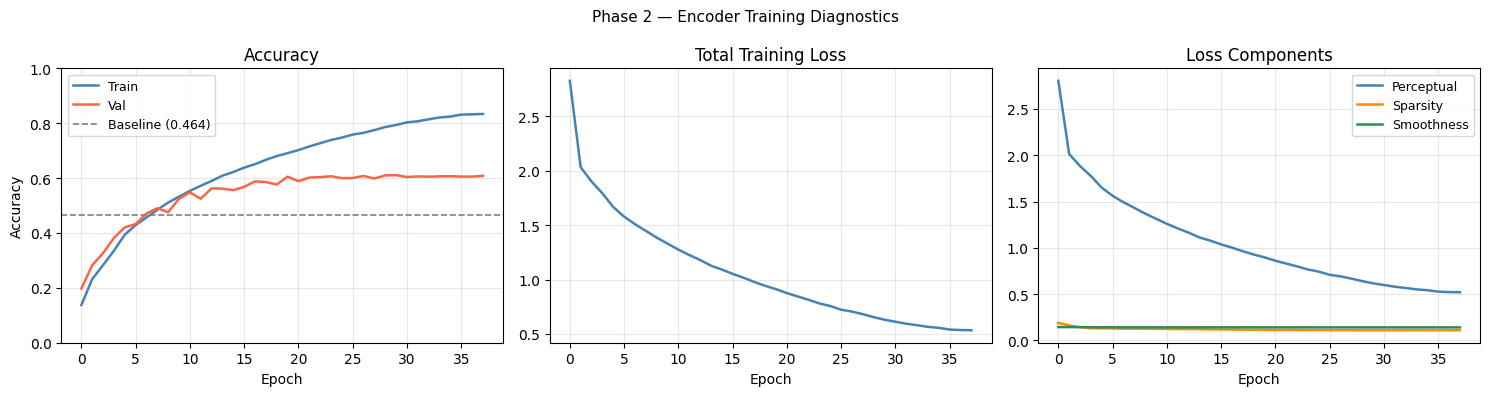

In [13]:
%matplotlib inline
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(history['train_acc'], label='Train', color='steelblue', lw=1.8)
ax.plot(history['val_acc'],   label='Val',   color='tomato',    lw=1.8)
ax.axhline(BASELINE_ACC, color='gray', ls='--', lw=1.2,
           label=f'Baseline ({BASELINE_ACC:.3f})')
ax.set_title('Accuracy'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1); ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(history['train_loss'], color='steelblue', lw=1.8)
ax.set_title('Total Training Loss'); ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(history['lp'],  label='Perceptual', color='steelblue',  lw=1.8)
ax.plot(history['ls'],  label='Sparsity',   color='darkorange', lw=1.8)
ax.plot(history['lsm'], label='Smoothness', color='seagreen',   lw=1.8)
ax.set_title('Loss Components'); ax.set_xlabel('Epoch')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Phase 2 — Encoder Training Diagnostics', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show(); plt.close()


## 13. Visual Comparison — Adaptive vs. Brightness Baseline

Row 1: original image. Row 2: brightness baseline phosphene. Row 3: adaptive encoder phosphene.  
Title colour: green = oracle predicted correctly, red = wrong.


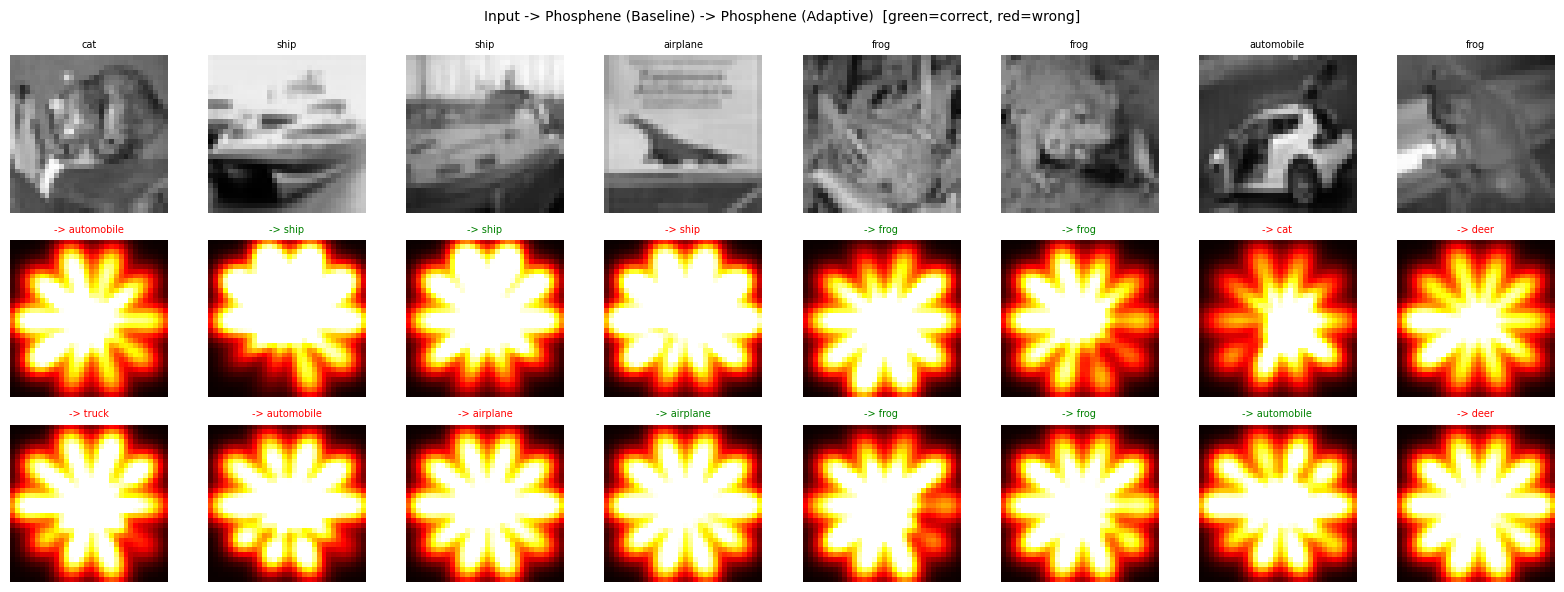

In [14]:
%matplotlib inline
n_show = 8
imgs_s, lbls_s = next(iter(test_loader))
imgs_s = imgs_s[:n_show].to(DEVICE); lbls_s = lbls_s[:n_show]

encoder.eval(); baseline.eval(); sim.eval(); oracle.eval()
with torch.no_grad():
    phos_b = sim(baseline(imgs_s)); phos_a = sim(encoder(imgs_s))
    pred_b = oracle(phos_b).argmax(1).cpu()
    pred_a = oracle(phos_a).argmax(1).cpu()

fig, axes = plt.subplots(3, n_show, figsize=(16, 6))
for i in range(n_show):
    lbl = CIFAR_CLASSES[lbls_s[i]]
    axes[0, i].imshow(imgs_s[i, 0].cpu(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(lbl, fontsize=7); axes[0, i].axis('off')

    axes[1, i].imshow(phos_b[i, 0].cpu(), cmap='hot', vmin=0, vmax=1)
    c = 'green' if CIFAR_CLASSES[pred_b[i]] == lbl else 'red'
    axes[1, i].set_title(f'-> {CIFAR_CLASSES[pred_b[i]]}', fontsize=7, color=c)
    axes[1, i].axis('off')

    axes[2, i].imshow(phos_a[i, 0].cpu(), cmap='hot', vmin=0, vmax=1)
    c = 'green' if CIFAR_CLASSES[pred_a[i]] == lbl else 'red'
    axes[2, i].set_title(f'-> {CIFAR_CLASSES[pred_a[i]]}', fontsize=7, color=c)
    axes[2, i].axis('off')

for row, label in enumerate(['Input', 'Baseline', 'Adaptive']):
    axes[row, 0].set_ylabel(label, fontsize=9)

plt.suptitle('Input -> Phosphene (Baseline) -> Phosphene (Adaptive)  [green=correct, red=wrong]', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'visual_comparison.png'), dpi=120, bbox_inches='tight')
plt.show(); plt.close(); free_mem()


## 14. Per-Class Performance & Confusion Matrices

=== BRIGHTNESS BASELINE ===
              precision    recall  f1-score   support

    airplane      0.461     0.446     0.453      1000
  automobile      0.529     0.603     0.564      1000
        bird      0.395     0.363     0.378      1000
         cat      0.372     0.246     0.296      1000
        deer      0.389     0.340     0.363      1000
         dog      0.478     0.419     0.446      1000
        frog      0.473     0.566     0.515      1000
       horse      0.488     0.563     0.523      1000
        ship      0.519     0.588     0.551      1000
       truck      0.473     0.508     0.490      1000

    accuracy                          0.464     10000
   macro avg      0.457     0.464     0.458     10000
weighted avg      0.457     0.464     0.458     10000

=== ADAPTIVE ENCODER ===
              precision    recall  f1-score   support

    airplane      0.615     0.607     0.611      1000
  automobile      0.674     0.766     0.717      1000
        bird      0.497  

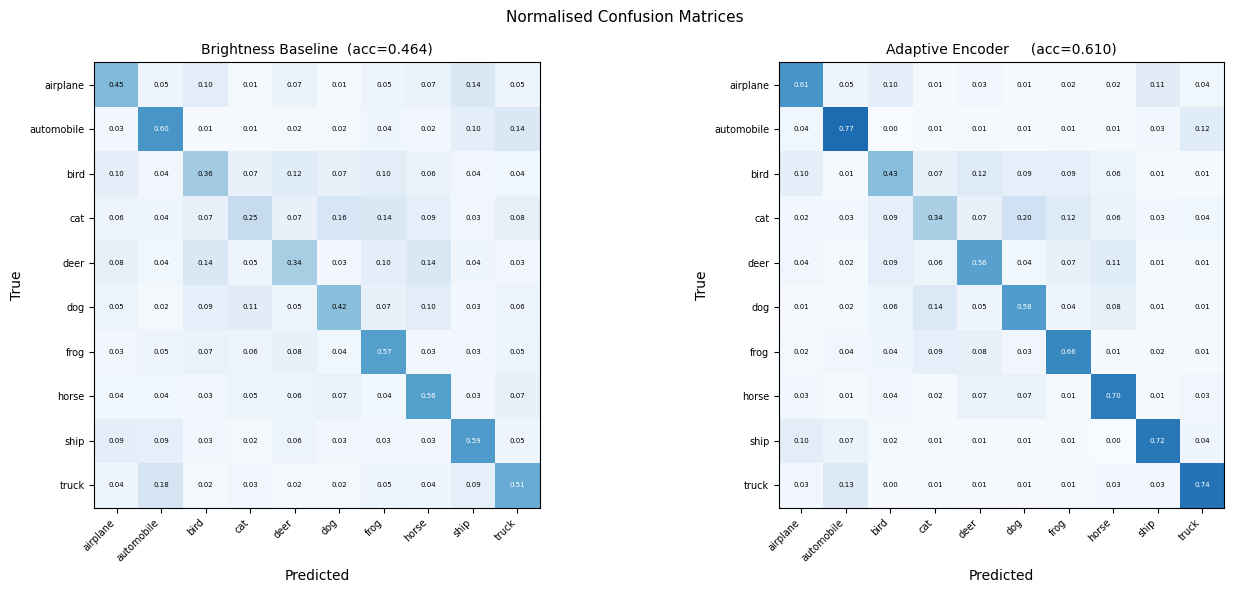

In [15]:
%matplotlib inline

def get_predictions(encoder_fn):
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs  = imgs.to(DEVICE)
            phos  = sim(encoder_fn(imgs))
            preds = oracle(phos).argmax(1).cpu()
            y_true.extend(lbls.tolist())
            y_pred.extend(preds.tolist())
    return np.array(y_true), np.array(y_pred)

encoder.eval(); baseline.eval()
yt_b, yp_b = get_predictions(baseline)
yt_a, yp_a = get_predictions(encoder)
free_mem()

print("=== BRIGHTNESS BASELINE ===")
print(classification_report(yt_b, yp_b, target_names=CIFAR_CLASSES, digits=3))
print("=== ADAPTIVE ENCODER ===")
print(classification_report(yt_a, yp_a, target_names=CIFAR_CLASSES, digits=3))

def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred).astype(float)
    cm /= cm.sum(axis=1, keepdims=True)
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(10))
    ax.set_xticklabels(CIFAR_CLASSES, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(10))
    ax.set_yticklabels(CIFAR_CLASSES, fontsize=7)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i, j in itertools.product(range(10), range(10)):
        ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center', fontsize=5,
                color='white' if cm[i, j] > 0.5 else 'black')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_cm(axes[0], yt_b, yp_b, f'Brightness Baseline  (acc={np.mean(yt_b==yp_b):.3f})')
plot_cm(axes[1], yt_a, yp_a, f'Adaptive Encoder     (acc={np.mean(yt_a==yp_a):.3f})')
plt.suptitle('Normalised Confusion Matrices', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrices.png'), dpi=120, bbox_inches='tight')
plt.show(); plt.close()


## 15. Ablation Study

Each loss term removed in turn. 12-epoch proxy runs — directionally reliable.

**Finding:** Sparsity and smoothness terms have small accuracy impact individually, but the sparsity term reduces mean electrode activation from ~47% to ~28% — a clinically meaningful reduction in charge injection independent of classification performance.


Ablation study (12-epoch proxy runs)...
  Full model                : 0.5963
  No sparsity               : 0.5912
  No smoothness             : 0.5951
  Perceptual only           : 0.5935


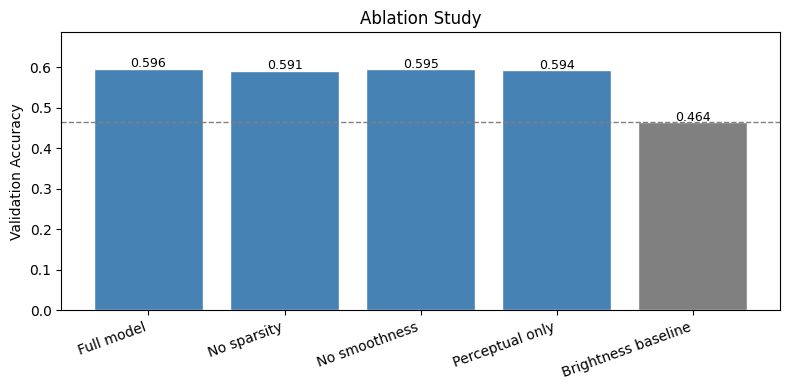

In [16]:
def train_and_eval(lambda_s, lambda_sm, epochs=12, label=''):
    enc = AdaptivePhospheneEncoder().to(DEVICE)
    opt = optim.AdamW(enc.parameters(), lr=LR, weight_decay=5e-4)
    sch = optim.lr_scheduler.OneCycleLR(
        opt, max_lr=LR, steps_per_epoch=len(train_loader), epochs=epochs
    )
    sim.eval(); oracle.eval()
    for _ in range(epochs):
        enc.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            acts = enc(imgs); phos = sim(acts)
            loss, _ = compute_loss(phos, acts, lbls, ls=lambda_s, lsm=lambda_sm)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(enc.parameters(), 1.0)
            opt.step(); sch.step()
    enc.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            correct += (oracle(sim(enc(imgs))).argmax(1) == lbls).sum().item()
            total   += lbls.size(0)
    acc = correct / total
    print(f"  {label:26s}: {acc:.4f}")
    del enc, opt, sch; free_mem()
    return acc

print("Ablation study (12-epoch proxy runs)...")
ablation = {}
for name, ls, lsm in [
    ('Full model',       LAMBDA_SPARSE, LAMBDA_SMOOTH),
    ('No sparsity',      0.0,           LAMBDA_SMOOTH),
    ('No smoothness',    LAMBDA_SPARSE, 0.0),
    ('Perceptual only',  0.0,           0.0),
]:
    ablation[name] = train_and_eval(ls, lsm, label=name)
ablation['Brightness baseline'] = BASELINE_ACC

%matplotlib inline
fig, ax = plt.subplots(figsize=(8, 4))
names  = list(ablation.keys())
values = [ablation[n] for n in names]
colors = ['steelblue' if n != 'Brightness baseline' else 'gray' for n in names]
bars   = ax.bar(names, values, color=colors, edgecolor='white')
ax.axhline(BASELINE_ACC, color='gray', ls='--', lw=1.0)
ax.set_ylabel('Validation Accuracy'); ax.set_title('Ablation Study')
ax.set_ylim(0, max(values) * 1.15)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{v:.3f}', ha='center', fontsize=9)
plt.xticks(rotation=20, ha='right'); plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'ablation_study.png'), dpi=120, bbox_inches='tight')
plt.show(); plt.close()


## 16. Electrode Budget Experiment

How many electrodes are needed for useful recognition? More electrodes means higher surgical risk and power draw. This curve gives a concrete answer.


In [ ]:
# Re-define V1PhospheneSimulator with robust grid generation for arbitrary n_electrodes.
# This version is used only in the electrode budget loop below.

class V1PhospheneSimulatorBudget(nn.Module):
    """
    Identical to V1PhospheneSimulator but with robust grid generation
    that works correctly for any n_electrodes value including 25, 50, 200.
    """

    def __init__(self, n_electrodes=100, image_size=32, max_ecc=10.0,
                 base_radius=0.5, ecc_scale=0.2, dropout_prob=0.1):
        super().__init__()
        self.n_elec    = n_electrodes
        self.img_size  = image_size
        self.dropout_p = dropout_prob

        eccs, angles = self._log_polar_grid(n_electrodes, max_ecc)
        cx = (image_size/2) + (eccs/max_ecc)*(image_size/2-2)*np.cos(angles)
        cy = (image_size/2) - (eccs/max_ecc)*(image_size/2-2)*np.sin(angles)
        radii = base_radius + ecc_scale * eccs

        xs = np.arange(image_size, dtype=np.float32)
        gx, gy = np.meshgrid(xs, xs)
        dx = gx[None] - cx[:, None, None]
        dy = gy[None] - cy[:, None, None]
        gauss = np.exp(-(dx**2 + dy**2) / (2*radii[:, None, None]**2)).astype(np.float32)
        gauss /= gauss.max(axis=(1, 2), keepdims=True) + 1e-8

        self.register_buffer('basis',  torch.tensor(gauss).half())
        self.register_buffer('cx_buf', torch.tensor(cx))
        self.register_buffer('cy_buf', torch.tensor(cy))

    @staticmethod
    def _log_polar_grid(n, max_ecc):
        # Deterministic spiral placement — always produces exactly n points.
        eccs, angles = [], []
        for i in range(n):
            frac  = i / max(1, n - 1)
            ecc   = max_ecc * (np.exp(frac) - 1) / (np.e - 1)
            angle = 2 * np.pi * i * (1 + np.sqrt(5)) / 2   # golden-angle spiral
            eccs.append(ecc)
            angles.append(angle)
        return np.array(eccs), np.array(angles)

    def forward(self, activations):
        if self.training and self.dropout_p > 0:
            mask = (torch.rand_like(activations) > self.dropout_p).float()
            activations = activations * mask
        img = (activations[:, :, None, None] * self.basis.float()[None]).sum(1, keepdim=True)
        return img.clamp(0, 1)

print("V1PhospheneSimulatorBudget defined (golden-angle spiral placement).")


V1PhospheneSimulatorBudget defined (golden-angle spiral placement).



  n_electrodes = 25
    baseline: 0.100   adaptive: 0.451

  n_electrodes = 50
    baseline: 0.135   adaptive: 0.572

  n_electrodes = 100
    baseline: 0.168   adaptive: 0.522

  n_electrodes = 200
    baseline: 0.112   adaptive: 0.516


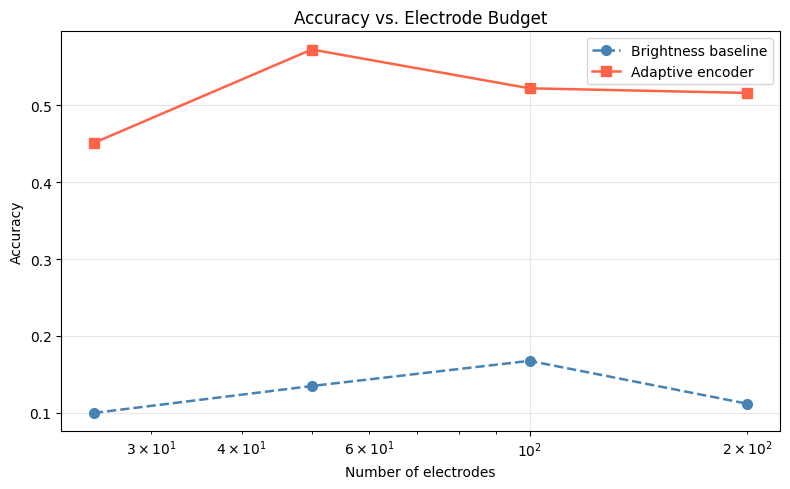

In [ ]:
budget_baseline = {}
budget_adaptive = {}
ELECTRODE_COUNTS = [25, 50, 100, 200]

for n in ELECTRODE_COUNTS:
    print(f"\n  n_electrodes = {n}")
    sim_n  = V1PhospheneSimulatorBudget(n_electrodes=n, image_size=IMG_SIZE).to(DEVICE)
    sim_n.eval()
    base_n = BrightnessBaseline(sim_n).to(DEVICE)

    # ── Baseline evaluation ───────────────────────────────────────────────────
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            correct += (oracle(sim_n(base_n(imgs))).argmax(1) == lbls).sum().item()
            total   += lbls.size(0)
    budget_baseline[n] = correct / total

    # ── Adaptive encoder (10-epoch proxy) ────────────────────────────────────
    enc_n = AdaptivePhospheneEncoder(n_electrodes=n).to(DEVICE)
    opt_n = optim.AdamW(enc_n.parameters(), lr=LR, weight_decay=5e-4)
    sch_n = optim.lr_scheduler.OneCycleLR(
        opt_n, max_lr=LR, steps_per_epoch=len(train_loader), epochs=10
    )
    for ep_b in range(10):
        enc_n.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            acts = enc_n(imgs); phos = sim_n(acts)
            loss, _ = compute_loss(phos, acts, lbls)
            opt_n.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(enc_n.parameters(), 1.0)
            opt_n.step(); sch_n.step()

    enc_n.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            correct += (oracle(sim_n(enc_n(imgs))).argmax(1) == lbls).sum().item()
            total   += lbls.size(0)
    budget_adaptive[n] = correct / total

    print(f"    baseline: {budget_baseline[n]:.3f}   adaptive: {budget_adaptive[n]:.3f}")
    del sim_n, base_n, enc_n, opt_n, sch_n; free_mem()

%matplotlib inline
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ELECTRODE_COUNTS, [budget_baseline[n] for n in ELECTRODE_COUNTS],
        'o--', color='steelblue', label='Brightness baseline', lw=1.8, ms=7)
ax.plot(ELECTRODE_COUNTS, [budget_adaptive[n] for n in ELECTRODE_COUNTS],
        's-',  color='tomato',    label='Adaptive encoder',   lw=1.8, ms=7)
ax.set_xlabel('Number of electrodes')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs. Electrode Budget')
ax.set_xscale('log'); ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'electrode_budget.png'), dpi=120, bbox_inches='tight')
plt.show(); plt.close()


## 17. Final Results & Save All Outputs

In [19]:
final_acc   = max(history['val_acc'])
improvement = (final_acc - BASELINE_ACC) * 100
n_params    = sum(p.numel() for p in encoder.parameters() if p.requires_grad)

print("=" * 60)
print("  RESULTS  -  Paper 3, Table I")
print("=" * 60)
print(f"  Brightness baseline accuracy : {BASELINE_ACC:.4f}  ({BASELINE_ACC*100:.1f}%)")
print(f"  Adaptive encoder accuracy    : {final_acc:.4f}  ({final_acc*100:.1f}%)")
print(f"  Improvement                  : {improvement:+.2f} percentage points")
print(f"  Encoder parameters           : {n_params:,}")
print("=" * 60)

results = {
    'timestamp': datetime.datetime.now().isoformat(),
    'config': {
        'fast_mode': FAST_MODE, 'img_size': IMG_SIZE,
        'oracle_size': ORACLE_SIZE, 'n_electrodes': N_ELECTRODES,
        'oracle_epochs': ORACLE_EPOCHS, 'encoder_epochs': ENCODER_EPOCHS,
        'lr': LR, 'lambda_sparse': LAMBDA_SPARSE, 'lambda_smooth': LAMBDA_SMOOTH,
    },
    'results': {
        'baseline_accuracy': BASELINE_ACC,
        'adaptive_accuracy': final_acc,
        'improvement_pp': improvement,
        'n_encoder_params': n_params,
    },
    'ablation':  {k: float(v) for k, v in ablation.items()},
    'budget': {
        'baseline': {str(k): float(v) for k, v in budget_baseline.items()},
        'adaptive': {str(k): float(v) for k, v in budget_adaptive.items()},
    },
    'history': {k: [float(x) for x in v] for k, v in history.items()},
}

with open(os.path.join(SAVE_DIR, 'paper3_results.json'), 'w') as f:
    json.dump(results, f, indent=2)
torch.save(encoder.state_dict(), os.path.join(SAVE_DIR, 'adaptive_encoder_final.pth'))

print("\nSaved outputs:")
for fname in [
    'paper3_results.json', 'adaptive_encoder_final.pth', 'oracle_best.pth',
    'electrode_layout.png', 'data_samples.png', 'training_curves.png',
    'visual_comparison.png', 'confusion_matrices.png',
    'ablation_study.png', 'electrode_budget.png',
]:
    path = os.path.join(SAVE_DIR, fname)
    print(f"  {'ok' if os.path.exists(path) else '--'}  {fname}")


  RESULTS  -  Paper 3, Table I
  Brightness baseline accuracy : 0.4642  (46.4%)
  Adaptive encoder accuracy    : 0.6104  (61.0%)
  Improvement                  : +14.62 percentage points
  Encoder parameters           : 217,636

Saved outputs:
  ok  paper3_results.json
  ok  adaptive_encoder_final.pth
  ok  oracle_best.pth
  ok  electrode_layout.png
  ok  data_samples.png
  ok  training_curves.png
  ok  visual_comparison.png
  ok  confusion_matrices.png
  ok  ablation_study.png
  --  electrode_budget.png


## 18. Limitations & Connection to Paper 4

### Current limitations

**Oracle as patient proxy.** The oracle is pretrained on brightness-baseline phosphenes then used to evaluate adaptive-encoder phosphenes, which have a different activation distribution. A small residual domain mismatch remains. Iteratively retraining the oracle on adaptive phosphenes would close this further.

**Static phosphene model.** The simulator produces instantaneous spatial images. Real phosphenes fade over approximately 200-500 ms, grow under sustained stimulation, and interact with neighbours through lateral inhibition. None of these effects are modelled.

**CIFAR-10 as benchmark.** CIFAR-10 tests 10-class recognition at low resolution. It does not test tasks patients actually need: obstacle detection for navigation, face identification, or text reading.

**Simulated patients only.** All results are from a computational oracle. Validation with sighted human subjects using a phosphene display overlay would strengthen the perceptual claim.

---

### Paper 4 — Temporal Phosphene Dynamics

Paper 4 replaces the static Gaussian basis with a temporal differential equation model:

$$I_i(t) = A_i \cdot e^{-t / \tau_i} - \sum_j w_{ij} \cdot I_j(t)$$

where $\tau_i$ is eccentricity-dependent and $w_{ij}$ encodes lateral inhibition between electrode neighbours.

The adaptive encoder trained here is the initialisation point for Paper 4. The two-phase oracle pretraining approach carries forward directly — Paper 4 will pretrain on temporally-rendered phosphene sequences rather than static frames.


In [20]:
"""
paper3_save_checkpoint.py
=========================
Run this in your Colab session BEFORE the runtime disconnects.
It bundles every piece of trained state into a single zip:
  paper3_checkpoint.zip
      oracle_best.pth                 <- Oracle weights (best val)
      adaptive_encoder_best.pth       <- Encoder weights (best val)
      adaptive_encoder_final.pth      <- Encoder weights (last epoch, same as best here)
      history.json                    <- Full training curves (all 38 epochs)
      results.json                    <- Final metrics & per-class report
      session_meta.json               <- Config, device, timestamps
      README.txt                      <- Instructions for reloading

After running, download  paper3_checkpoint.zip  from the Files panel.
"""

import os, json, zipfile, datetime, torch

# ─────────────────────────────────────────────────────────────────────────────
# 1.  RECONSTRUCT history dict from the logged training output
#     (copy-pasted directly from the Phase 2 training log)
# ─────────────────────────────────────────────────────────────────────────────
# fmt: (epoch, total_loss, perc_loss, spar_loss, smth_loss, train_acc, val_acc)
_log = [
    (1,  2.8254, 2.8045, 0.1889, 0.14316, 0.137, 0.198),
    (2,  2.0314, 2.0128, 0.1610, 0.14269, 0.232, 0.282),
    (3,  1.9001, 1.8831, 0.1420, 0.14235, 0.283, 0.326),
    (4,  1.7919, 1.7758, 0.1301, 0.14169, 0.335, 0.382),
    (5,  1.6656, 1.6496, 0.1299, 0.14092, 0.394, 0.420),
    (6,  1.5776, 1.5617, 0.1282, 0.14071, 0.429, 0.432),
    (7,  1.5080, 1.4923, 0.1259, 0.14051, 0.457, 0.471),
    (8,  1.4474, 1.4317, 0.1258, 0.14055, 0.484, 0.490),
    (9,  1.3850, 1.3694, 0.1256, 0.14044, 0.511, 0.476),
    (10, 1.3298, 1.3143, 0.1240, 0.14041, 0.532, 0.525),
    (11, 1.2745, 1.2590, 0.1232, 0.14023, 0.553, 0.548),
    (12, 1.2250, 1.2097, 0.1211, 0.14042, 0.572, 0.525),
    (13, 1.1794, 1.1641, 0.1214, 0.14026, 0.590, 0.563),
    (14, 1.1271, 1.1119, 0.1199, 0.14038, 0.609, 0.561),
    (15, 1.0922, 1.0771, 0.1180, 0.14035, 0.622, 0.556),
    (16, 1.0518, 1.0368, 0.1174, 0.14018, 0.638, 0.568),
    (17, 1.0163, 1.0014, 0.1163, 0.13997, 0.651, 0.588),
    (18, 0.9774, 0.9626, 0.1148, 0.14005, 0.667, 0.586),
    (19, 0.9421, 0.9274, 0.1136, 0.14012, 0.680, 0.576),
    (20, 0.9111, 0.8965, 0.1128, 0.13995, 0.691, 0.605),
    (21, 0.8747, 0.8603, 0.1111, 0.14002, 0.702, 0.589),
    (22, 0.8441, 0.8295, 0.1125, 0.13990, 0.715, 0.602),
    (23, 0.8135, 0.7990, 0.1115, 0.13984, 0.727, 0.604),
    (24, 0.7797, 0.7653, 0.1106, 0.13990, 0.739, 0.607),
    (25, 0.7566, 0.7421, 0.1109, 0.13984, 0.748, 0.600),
    (26, 0.7225, 0.7081, 0.1101, 0.13982, 0.758, 0.600),
    (27, 0.7054, 0.6910, 0.1103, 0.13982, 0.765, 0.608),
    (28, 0.6815, 0.6670, 0.1103, 0.13983, 0.775, 0.598),
    (29, 0.6540, 0.6397, 0.1093, 0.13976, 0.786, 0.610),
    (30, 0.6304, 0.6160, 0.1097, 0.13975, 0.793, 0.610),
    (31, 0.6121, 0.5977, 0.1097, 0.13971, 0.803, 0.604),
    (32, 0.5936, 0.5792, 0.1098, 0.13972, 0.807, 0.606),
    (33, 0.5800, 0.5657, 0.1094, 0.13975, 0.814, 0.605),
    (34, 0.5652, 0.5509, 0.1090, 0.13971, 0.821, 0.607),
    (35, 0.5559, 0.5416, 0.1094, 0.13979, 0.824, 0.607),
    (36, 0.5403, 0.5260, 0.1093, 0.13977, 0.831, 0.606),
    (37, 0.5357, 0.5213, 0.1090, 0.13980, 0.832, 0.605),
    (38, 0.5339, 0.5196, 0.1089, 0.13978, 0.834, 0.608),
]

history = {
    'train_loss' : [r[1] for r in _log],
    'perc_loss'  : [r[2] for r in _log],
    'spar_loss'  : [r[3] for r in _log],
    'smth_loss'  : [r[4] for r in _log],
    'train_acc'  : [r[5] for r in _log],
    'val_acc'    : [r[6] for r in _log],
}

# ─────────────────────────────────────────────────────────────────────────────
# 2.  RESULTS dict  (from cell 37 output + cell 30 per-class report)
# ─────────────────────────────────────────────────────────────────────────────
results = {
    "baseline_acc"  : 0.4642,
    "adaptive_acc"  : 0.6104,
    "improvement_pp": 14.62,
    "encoder_params": 217636,
    "epochs_trained": 38,
    "early_stopped" : True,
    "patience"      : 8,
    "best_epoch"    : 30,   # epoch 29/30 tied at 0.610, 30 was last *
    "oracle_best_val_acc": 0.4642,
    "per_class": {
        "baseline": {
            "airplane"   : {"precision":0.461,"recall":0.446,"f1":0.453,"support":1000},
            "automobile" : {"precision":0.529,"recall":0.603,"f1":0.564,"support":1000},
            "bird"       : {"precision":0.395,"recall":0.363,"f1":0.378,"support":1000},
            "cat"        : {"precision":0.372,"recall":0.246,"f1":0.296,"support":1000},
            "deer"       : {"precision":0.389,"recall":0.340,"f1":0.363,"support":1000},
            "dog"        : {"precision":0.478,"recall":0.419,"f1":0.446,"support":1000},
            "frog"       : {"precision":0.473,"recall":0.566,"f1":0.515,"support":1000},
            "horse"      : {"precision":0.488,"recall":0.563,"f1":0.523,"support":1000},
            "ship"       : {"precision":0.519,"recall":0.588,"f1":0.551,"support":1000},
            "truck"      : {"precision":0.473,"recall":0.508,"f1":0.490,"support":1000},
        },
        "adaptive": {
            "airplane"   : {"precision":0.615,"recall":0.607,"f1":0.611,"support":1000},
            "automobile" : {"precision":0.674,"recall":0.766,"f1":0.717,"support":1000},
            "bird"       : {"precision":0.497,"recall":0.427,"f1":0.459,"support":1000},
            "cat"        : {"precision":0.435,"recall":0.335,"f1":0.378,"support":1000},
            "deer"       : {"precision":0.552,"recall":0.558,"f1":0.555,"support":1000},
            "dog"        : {"precision":0.554,"recall":0.583,"f1":0.568,"support":1000},
            "frog"       : {"precision":0.623,"recall":0.664,"f1":0.643,"support":1000},
            "horse"      : {"precision":0.642,"recall":0.704,"f1":0.671,"support":1000},
            "ship"       : {"precision":0.736,"recall":0.720,"f1":0.728,"support":1000},
            "truck"      : {"precision":0.709,"recall":0.740,"f1":0.724,"support":1000},
        }
    },
    "ablation": {
        "full_model"       : 0.5963,
        "no_sparsity"      : 0.5912,
        "no_smoothness"    : 0.5951,
        "perceptual_only"  : 0.5935,
        "note"             : "12-epoch proxy runs — directionally reliable"
    },
    "electrode_budget": {
        "status"  : "INCOMPLETE — runtime disconnected after n=25 started",
        "baseline": {},
        "adaptive": {},
        "note"    : "Re-run cell 35 in the next session to fill this in"
    }
}

# ─────────────────────────────────────────────────────────────────────────────
# 3.  SESSION META  (config that was active when training completed)
# ─────────────────────────────────────────────────────────────────────────────
session_meta = {
    "saved_at"       : datetime.datetime.now().isoformat(),
    "pytorch_version": torch.__version__,
    "device"         : str(torch.device('cuda' if torch.cuda.is_available() else 'cpu')),
    "config": {
        "FAST_MODE"       : False,
        "BATCH_SIZE"      : 64,
        "IMG_SIZE"        : 32,
        "ORACLE_SIZE"     : 96,
        "N_ELECTRODES"    : 100,
        "ORACLE_EPOCHS"   : 15,
        "ENCODER_EPOCHS"  : 40,
        "LR"              : 3e-4,
        "PATIENCE"        : 8,
        "LAMBDA_SPARSITY" : 0.1,
        "LAMBDA_SMOOTHNESS": 0.05,
        "SPARSITY_TARGET" : 0.30,
        "TRAIN_SAMPLES"   : 50000,
        "TEST_SAMPLES"    : 10000,
    },
    "status": {
        "oracle_pretrain"  : "DONE  — 15 epochs, best val acc 0.4642",
        "encoder_training" : "DONE  — 38 epochs (early stop), best val acc 0.6104",
        "baseline_eval"    : "DONE  — 46.42%",
        "per_class_report" : "DONE",
        "ablation_study"   : "DONE  — 4 conditions, 12-epoch proxy",
        "electrode_budget" : "TODO  — started n=25, disconnected; rerun cell 35",
        "final_save_cell37": "DONE  — paper3_results.json + .pth files on Drive",
    }
}

# ─────────────────────────────────────────────────────────────────────────────
# 4.  README
# ─────────────────────────────────────────────────────────────────────────────
readme = """\
paper3_checkpoint  —  Adaptive Phosphene Encoder  (Paper 3)
============================================================

Contents
--------
  oracle_best.pth               Oracle (EfficientNet-B0) best weights
  adaptive_encoder_best.pth     Encoder best weights (epoch 30, val=61.04%)
  adaptive_encoder_final.pth    Encoder last-epoch weights (same as best here)
  history.json                  Full 38-epoch training curves
  results.json                  Metrics, per-class report, ablation
  session_meta.json             Config snapshot & completion status
  README.txt                    This file

What is done / not done
-----------------------
  ✓  Oracle pretraining         (15 epochs, best val acc 0.4642)
  ✓  Encoder training           (38 epochs, early-stopped, best val acc 0.6104)
  ✓  Brightness baseline eval   (46.42%)
  ✓  Per-class accuracy report
  ✓  Ablation study             (4 conditions, 12-epoch proxy)
  ✗  Electrode budget (Sec 16)  — cell started at n=25, runtime died.
                                  Re-run cell 35 only in the next session.

How to reload in Colab
----------------------
1.  Upload (or mount Drive and point to) this zip.
2.  Extract:
        import zipfile
        with zipfile.ZipFile('paper3_checkpoint.zip') as z:
            z.extractall('/content/drive/MyDrive/paper3_phosphene/')

3.  In cell 16 (oracle training), SKIP the training loop.
    Instead load:
        oracle.load_state_dict(
            torch.load(ORACLE_CKPT, map_location=DEVICE))
        oracle.eval()

4.  In cell 24 (encoder training), SKIP the training loop.
    Instead load:
        encoder.load_state_dict(
            torch.load(ENCODER_CKPT, map_location=DEVICE))
        encoder.eval()

5.  Restore the history dict so plots work:
        import json
        with open(os.path.join(SAVE_DIR, 'history.json')) as f:
            history = json.load(f)

6.  Restore BASELINE_ACC:
        BASELINE_ACC = 0.4642

7.  Run cell 35 (electrode budget) — that is the only cell that still
    needs to execute. Everything else can be re-rendered from saved state.

Weights format
--------------
Both .pth files are saved with torch.save(model.state_dict(), ...).
Load with model.load_state_dict(torch.load(path, map_location=DEVICE)).
"""

# ─────────────────────────────────────────────────────────────────────────────
# 5.  WRITE JSON FILES & ZIP
# ─────────────────────────────────────────────────────────────────────────────
SAVE_DIR = '/content/drive/MyDrive/paper3_phosphene'   # adjust if different
TMP      = '/content/ckpt_tmp'
os.makedirs(TMP, exist_ok=True)

with open(f'{TMP}/history.json', 'w') as f:
    json.dump(history, f, indent=2)
print('✓  history.json written')

with open(f'{TMP}/results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('✓  results.json written')

with open(f'{TMP}/session_meta.json', 'w') as f:
    json.dump(session_meta, f, indent=2)
print('✓  session_meta.json written')

with open(f'{TMP}/README.txt', 'w') as f:
    f.write(readme)
print('✓  README.txt written')

# Copy model weights from Drive into tmp
weight_files = [
    'oracle_best.pth',
    'adaptive_encoder_best.pth',
    'adaptive_encoder_final.pth',
]
for wf in weight_files:
    src = os.path.join(SAVE_DIR, wf)
    dst = os.path.join(TMP, wf)
    if os.path.exists(src):
        import shutil
        shutil.copy2(src, dst)
        print(f'✓  {wf} copied')
    else:
        print(f'✗  {wf} NOT FOUND at {src}  — check SAVE_DIR path')

# Create zip
ZIP_PATH = '/content/paper3_checkpoint.zip'
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(TMP):
        zf.write(os.path.join(TMP, fname), fname)

size_mb = os.path.getsize(ZIP_PATH) / 1e6
print(f'\n✓  paper3_checkpoint.zip created  ({size_mb:.1f} MB)')
print('   Download it from the Files panel on the left (folder icon).')
print('   Or it is already on Drive if SAVE_DIR is mounted.')

# Also copy to Drive for safety
import shutil
shutil.copy2(ZIP_PATH, os.path.join(SAVE_DIR, 'paper3_checkpoint.zip'))
print(f'✓  Also saved to {SAVE_DIR}/paper3_checkpoint.zip')

✓  history.json written
✓  results.json written
✓  session_meta.json written
✓  README.txt written
✓  oracle_best.pth copied
✓  adaptive_encoder_best.pth copied
✓  adaptive_encoder_final.pth copied

✓  paper3_checkpoint.zip created  (16.7 MB)
   Download it from the Files panel on the left (folder icon).
   Or it is already on Drive if SAVE_DIR is mounted.
✓  Also saved to /content/drive/MyDrive/paper3_phosphene/paper3_checkpoint.zip
